# XGBoost

**Данные:** `data/train_data_v2.csv` (6 200 строк, 67 признаков)  
**Модель:** XGBRegressor на GPU (`tree_method='hist'`, `device='cuda'`)  
**Подбор гиперпараметров:** Optuna (100 trials)  
**Метрика:** RMSE

In [14]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
DATA_PATH = Path('../data/train_data_v2.csv')
TARGET = 'target'
MODEL_SAVE_PATH = Path('../models/xgboost_best.json')

pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Загрузка данных

In [15]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df[TARGET].describe())

Shape: (6200, 134)
count   6200.0000
mean       0.0008
std        0.0859
min       -0.1450
25%       -0.0612
50%       -0.0155
75%        0.0402
max        0.2186
Name: target, dtype: float64


## 2. Признаки

In [16]:
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center', 'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'nearest_offices_dist_m', 'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m', 'nearest_hotels_hostels_dist_m',
    'land_use_dist_m', 'city_center_dist_m', 'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m', 'count_banks_atms_300m',
    'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m',
    'count_education_300m', 'count_post_offices_300m',
    'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m',
    'count_hypermarkets_300m', 'count_markets_300m',
    'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = [
    'federal_district', 'city_size_category', 'land_use_type', 'atm_group',
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков: {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Итого признаков: 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 3. Подготовка данных

**Разбивка train / val / test = 70% / 15% / 15%**  
- Optuna и early stopping оптимизируют по **val** - модель не видит test до финального отчёта  
- Финальные метрики считаются один раз на **test**

In [17]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in CATEGORICAL_FEATURES:
    if col in X.columns:
        X[col] = X[col].fillna('unknown').astype(str)

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')

Train : (4339, 67)  (70%)
Val   : (931, 67)  (15%)
Test  : (930, 67)  (15%)


## 4. Препроцессинг

In [18]:
bin_cols  = [f for f in BINARY_FEATURES   if f in X.columns]
dist_cols = [f for f in DISTANCE_FEATURES if f in X.columns]
cnt_cols  = [f for f in COUNT_FEATURES    if f in X.columns]
econ_cols = [f for f in ECONOMIC_FEATURES if f in X.columns]
cat_cols  = [f for f in CATEGORICAL_FEATURES if f in X.columns]

log1p_tf = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

preprocessor = ColumnTransformer(
    transformers=[
        ('binary',   Pipeline([('imp', SimpleImputer(strategy='most_frequent'))]), bin_cols),
        ('distance', Pipeline([('imp', SimpleImputer(strategy='median')), ('log', log1p_tf), ('sc', StandardScaler())]), dist_cols),
        ('count',    Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), cnt_cols),
        ('economic', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), econ_cols),
        ('cat',      Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)
feat_names   = preprocessor.get_feature_names_out()
print(f'Train prep shape: {X_train_prep.shape}')

Train prep shape: (4339, 67)


## 5. DMatrix (XGBoost native format)

In [19]:
dtrain = xgb.DMatrix(X_train_prep, label=y_train, feature_names=list(feat_names))
dval   = xgb.DMatrix(X_val_prep,   label=y_val,   feature_names=list(feat_names))
dtest  = xgb.DMatrix(X_test_prep,  label=y_test,  feature_names=list(feat_names))
print(f'DMatrix: train={dtrain.num_row()}, val={dval.num_row()}, test={dtest.num_row()} rows')

DMatrix: train=4339, val=931, test=930 rows


In [20]:
def report_metrics(model_name, model, dm_tr, y_tr, dm_te, y_te, fit_time):
    best_iter = model.best_iteration
    t0 = time.perf_counter()
    y_pred_train = model.predict(dm_tr, iteration_range=(0, best_iter + 1))
    train_pred_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    y_pred_test = model.predict(dm_te, iteration_range=(0, best_iter + 1))
    test_pred_time = time.perf_counter() - t0
    def _m(yt, yp):
        return {'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
                'MAE':  round(float(mean_absolute_error(yt, yp)), 4),
                'R2':   round(float(r2_score(yt, yp)), 4)}
    train_m = _m(y_tr, y_pred_train)
    test_m  = _m(y_te, y_pred_test)
    table = pd.DataFrame([
        {'Split': 'Train', **train_m, 'Fit time, s': round(fit_time, 2), 'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',  **test_m,  'Fit time, s': float('nan'),        'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')
    print(f'\n{model_name}')
    display(table.style.format(
        {'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
         'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'},
        na_rep='-'
    ))
    return {
        'Model': model_name,
        'Test RMSE': test_m['RMSE'], 'Test MAE': test_m['MAE'], 'Test R2': test_m['R2'],
        'Fit time, s': round(fit_time, 2), 'Predict time, s': round(test_pred_time, 4),
    }

## 6. Baseline XGBoost

In [21]:
base_params = {
    'objective':        'reg:squarederror',
    'eval_metric':      'rmse',
    'tree_method':      'hist',
    'device':           'cuda',
    'learning_rate':    0.05,
    'max_depth':        6,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'seed':             RANDOM_STATE,
}

t0 = time.perf_counter()
xgb_baseline = xgb.train(
    base_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100,
)
fit_time_base = time.perf_counter() - t0

base_m = report_metrics('Baseline XGBoost', xgb_baseline, dtrain, y_train, dtest, y_test, fit_time_base)
rmse_base = base_m['Test RMSE']
mae_base  = base_m['Test MAE']
r2_base   = base_m['Test R2']

[0]	val-rmse:0.08260
[100]	val-rmse:0.04578
[200]	val-rmse:0.04517
[249]	val-rmse:0.04519

Baseline XGBoost


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0271,0.0212,0.9010,0.79,0.0064
Test,0.0451,0.0360,0.7276,-,0.0048


## 7. Подбор гиперпараметров (Optuna, 100 trials)

In [22]:
def objective(trial):
    params = {
        'objective':         'reg:squarederror',
        'eval_metric':       'rmse',
        'tree_method':       'hist',
        'device':            'cuda',
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'seed':              RANDOM_STATE,
    }
    result = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred = result.predict(dval, iteration_range=(0, result.best_iteration + 1))
    return np.sqrt(mean_squared_error(y_val, pred))

study = optuna.create_study(
    direction='minimize',
    study_name='xgboost_gpu',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE (val): {study.best_value:.4f}')
print('Best params:', study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]


Best RMSE (val): 0.0450
Best params: {'learning_rate': 0.04622396913976372, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.5659682166433864, 'colsample_bytree': 0.7741297411711878, 'colsample_bylevel': 0.800618439901423, 'reg_alpha': 0.0031711974021529335, 'reg_lambda': 0.01733478449653515, 'gamma': 0.0071364251358524205}


## 8. Финальная модель

In [23]:
final_params = dict(study.best_params)
final_params.update({
    'objective':   'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device':      'cuda',
    'seed':        RANDOM_STATE,
})

t0 = time.perf_counter()
xgb_final = xgb.train(
    final_params,
    dtrain,
    num_boost_round=2000,
    evals=[(dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=100,
)
fit_time_final = time.perf_counter() - t0

final_m = report_metrics('Final XGBoost (Optuna)', xgb_final, dtrain, y_train, dtest, y_test, fit_time_final)
rmse_final = final_m['Test RMSE']
mae_final  = final_m['Test MAE']
r2_final   = final_m['Test R2']
print(f'Best iteration: {xgb_final.best_iteration}')

[0]	val-rmse:0.08269
[100]	val-rmse:0.04521
[200]	val-rmse:0.04504
[300]	val-rmse:0.04500
[400]	val-rmse:0.04497
[441]	val-rmse:0.04499

Final XGBoost (Optuna)


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0316,0.0251,0.8656,1.10,0.0094
Test,0.0458,0.0368,0.7192,-,0.0081


Best iteration: 391


## 9. Финальная модель для сохранения

In [24]:
X_trainval_prep = preprocessor.transform(X_trainval)
dtrainval = xgb.DMatrix(X_trainval_prep, label=y_trainval, feature_names=list(feat_names))

final_params_save = dict(study.best_params)
final_params_save.update({
    'objective':   'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device':      'cuda',
    'seed':        RANDOM_STATE,
})

xgb_save = xgb.train(
    final_params_save,
    dtrainval,
    num_boost_round=xgb_final.best_iteration + 1,
    verbose_eval=100,
)

MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
xgb_save.save_model(str(MODEL_SAVE_PATH))
print(f'Model saved -> {MODEL_SAVE_PATH}')

Model saved -> ..\models\xgboost_best.json


## 10. Важность признаков

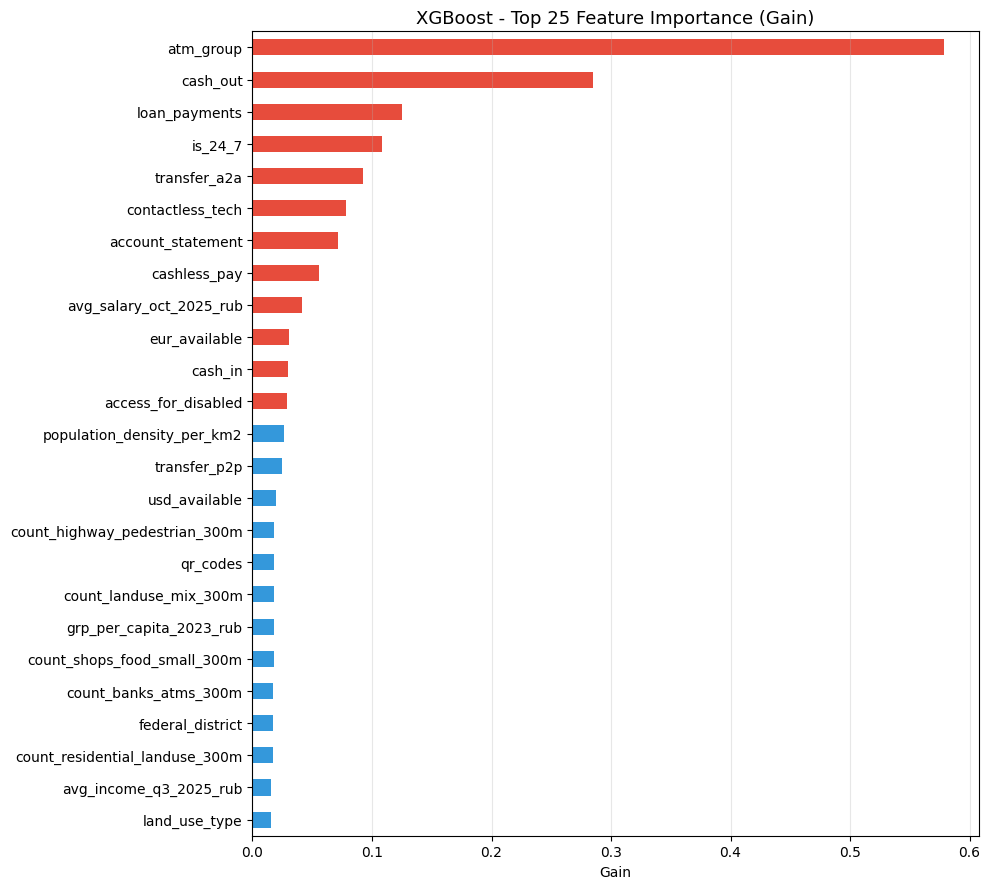


Top 15 features:
atm_group                    0.5786
cash_out                     0.2852
loan_payments                0.1251
is_24_7                      0.1087
transfer_a2a                 0.0926
contactless_tech             0.0780
account_statement            0.0717
cashless_pay                 0.0555
avg_salary_oct_2025_rub      0.0418
eur_available                0.0302
cash_in                      0.0299
access_for_disabled          0.0292
population_density_per_km2   0.0260
transfer_p2p                 0.0244
usd_available                0.0196


In [25]:
scores = xgb_final.get_score(importance_type='gain')
feat_imp = pd.Series(scores).sort_values(ascending=False)

feat_imp.index = [n.split('__', 1)[-1] if '__' in n else n for n in feat_imp.index]

fig, ax = plt.subplots(figsize=(10, 9))
top25 = feat_imp.head(25).iloc[::-1]
median_imp = top25.median()
colors = ['#e74c3c' if v > median_imp else '#3498db' for v in top25.values]
top25.plot.barh(ax=ax, color=colors)
ax.set_title('XGBoost - Top 25 Feature Importance (Gain)', fontsize=13)
ax.set_xlabel('Gain')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(feat_imp.head(15).to_string())

## 11. Итоги

In [26]:
summary = pd.DataFrame([
    {'Эксперимент': 'Baseline', 'RMSE': rmse_base,  'MAE': mae_base,  'R2': r2_base,
     'Fit time, s': base_m['Fit time, s'],  'Predict time, s': base_m['Predict time, s']},
    {'Эксперимент': 'Optuna',   'RMSE': rmse_final, 'MAE': mae_final, 'R2': r2_final,
     'Fit time, s': final_m['Fit time, s'], 'Predict time, s': final_m['Predict time, s']},
]).set_index('Эксперимент')

display(
    summary.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
             'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R2'])
)

,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Эксперимент,,,,,
Baseline,0.0451,0.0360,0.7276,0.79,0.0048
Optuna,0.0458,0.0368,0.7192,1.10,0.0081


In [ ]:
# Так как baseline оказался лучше optuna, перезапишем модель для сохранения
xgb_baseline.save_model(str(MODEL_SAVE_PATH))
print(f'Model saved -> {MODEL_SAVE_PATH}')

Model saved -> ..\models\xgboost_best.json
